# Análise Exploratória dos Dados (EDA)

## Objetivo

Este notebook tem como objetivo compreender o comportamento dos usuários no dataset RetailRocket, identificar padrões de navegação e fornecer subsídios para a construção de um sistema de recomendação baseado em embeddings e redes neurais.

O dataset possui quatro colunas:

- timestamp → momento da interação
- visitorid → identificador do usuário
- event → tipo da interação
- itemid → identificador do produto

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/events.csv")

df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 6 columns):
 #   Column         Dtype         
---  ------         -----         
 0   timestamp      int64         
 1   visitorid      int64         
 2   event          object        
 3   itemid         int64         
 4   transactionid  float64       
 5   datetime       datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 126.2+ MB


In [13]:
print(df.shape)

(2756101, 6)


In [4]:
df.isnull().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

In [5]:
df.describe()

,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


In [11]:
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

In [12]:
df["datetime"].dt.date.value_counts()

datetime
2015-07-26    32703
2015-07-27    28562
2015-07-25    27106
2015-05-18    27084
2015-07-14    26872
              ...  
2015-06-13    12270
2015-05-10    12143
2015-09-16    11495
2015-09-17    10128
2015-09-18     1528
Name: count, Length: 139, dtype: int64

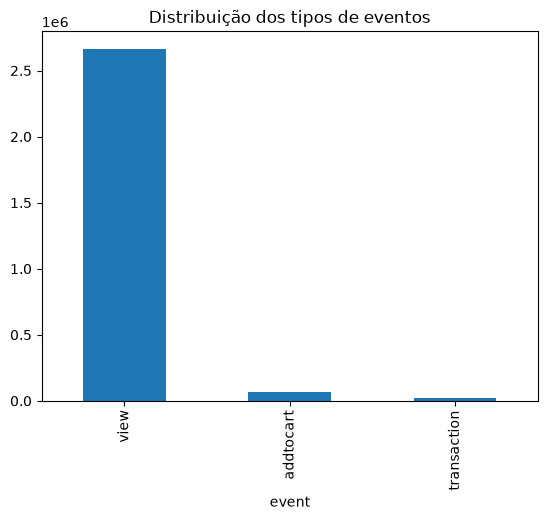

In [14]:
df["event"].value_counts().plot.bar()
plt.title("Distribuição dos tipos de eventos")
plt.show()

In [25]:
event_percent = (
    df["event"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

event_percent

event
view           96.67
addtocart       2.52
transaction     0.81
Name: proportion, dtype: float64

<Axes: xlabel='itemid'>

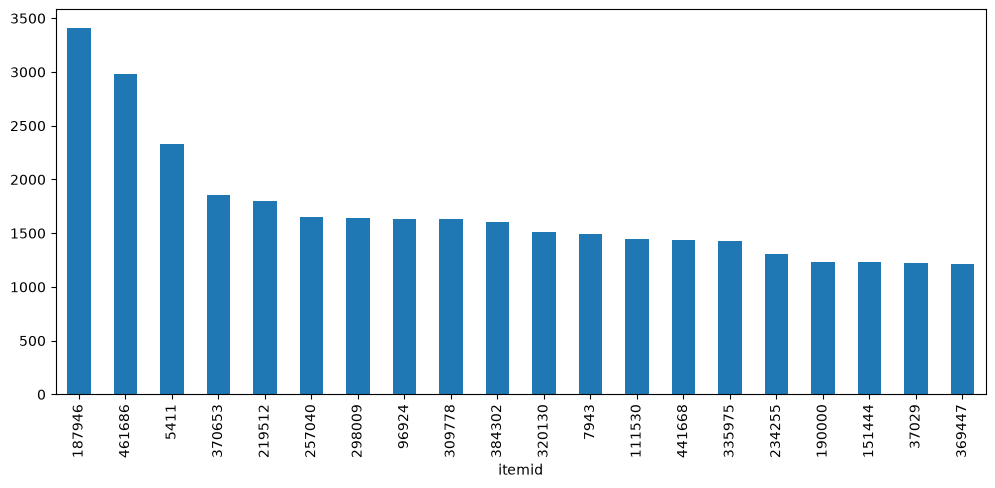

In [15]:
top = df["itemid"].value_counts().head(20)

top.plot.bar(figsize=(12,5))

<Axes: xlabel='visitorid'>

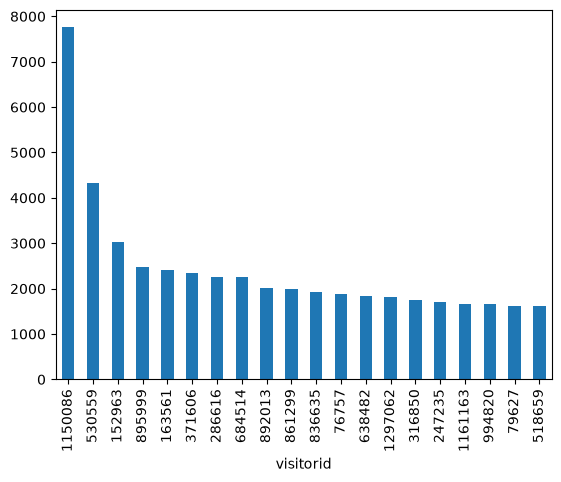

In [16]:
top_users = df["visitorid"].value_counts().head(20)

top_users.plot.bar()

<Axes: xlabel='datetime'>

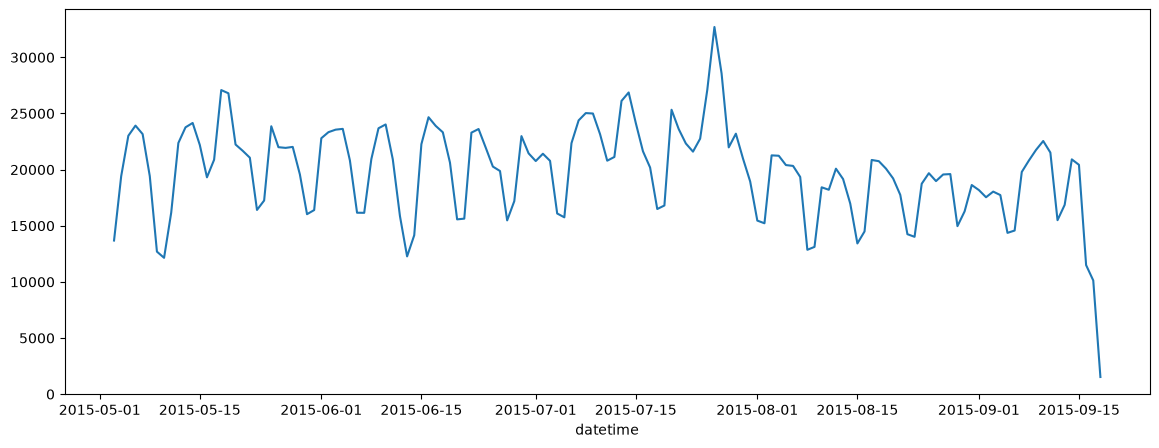

In [ ]:
interacoes = df.groupby(df["datetime"].dt.date).size()
interacoes.plot(figsize=(14,5))

In [19]:
interacoes_usuario = df.groupby("visitorid").size()
interacoes_usuario.describe()

count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64

In [21]:
interacoes_produto = df.groupby("itemid").size()
interacoes_produto.describe()

count    235061.000000
mean         11.725046
std          37.032101
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
dtype: float64

In [23]:
usuarios = df["visitorid"].nunique()
produtos = df["itemid"].nunique()

interacoes = len(df)

densidade = interacoes / (usuarios * produtos)

print(densidade)

8.32993210983756e-06


 ### Interpretação

A densidade extremamente baixa demonstra que apenas uma pequena fração das possíveis combinações usuário-produto possui interação registrada.

Essa característica é típica de sistemas de recomendação e justifica o uso de embeddings para representar usuários e produtos em um espaço vetorial de menor dimensão.

In [ ]:
## Conclusões da EDA

A análise mostrou que o dataset possui grande volume de interações, muitos usuários e muitos produtos distintos. A maior parte dos eventos corresponde a visualizações, enquanto compras representam uma parcela pequena dos registros.

Também foi observada alta esparsidade na matriz usuário-item, além de comportamento de cauda longa: poucos usuários e produtos concentram muitas interações, enquanto a maioria aparece poucas vezes.

Esses achados justificam o uso de um modelo de recomendação baseado em embeddings e rede neural MLP, pois essa abordagem consegue aprender representações latentes de usuários e produtos mesmo em cenários com dados esparsos.